# CA1: Dataframe Manipulation with Spotify Data

## Introduction
Pandas is an extremely powerful tool to handle large amounts of tabular data. In this compulsory assignment, you will use Pandas to explore one of the TA's personal spotify data in depth. \
\
Additional information:
- Feel free to create additional code cells if you feel that one cell per subtask is not sufficient.
- Remember, Pandas uses very efficient code to handle large amounts of data. For-loops are not efficient. If you ever have to use a for-loop to loop over the rows in the DataFrame, you have *probably* done something wrong.
- Label all graphs and charts if applicable.

## Task
I typically enjoy indie and rock music. I am a big fan of everything from old-fashioned rock and roll like Led Zeppelin and Jimi Hendrix, to newer indie artists like Joji and Lana Del Rey. This is why my spotify wrapped for 2023 came as quite a surprise:

<img src="spotifywrapped.PNG" alt="Image Description" width="20%">


Now, I'm no hater of pop music, but this was unexpected. 
For this assignment, you will investigate my listening habits, including a deep dive into my Ariana Grande listening habits, and try to find an answer to why she was my top artist; was there a fault in the spotify algorithm? Am I actually secretly an *Arianator*? (yes, I did have to look that up). Or am I just lying to myself about how often I listen to guilty pleasure music?

## Part 1: Initial loading and exploration

#### 1.0 Import necessary libraries: 
pandas, numpy, matplotlib.pyplot (other libraries such as seaborn or plotly are also allowed if you want prettier plots). It might also be a good idea to use **os** for task 2.0

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ---- Insert other imports ----

#### 1.1 Loading the data
Load the dataset in the file `streaming_history_0.csv` into a Pandas DataFrame called `df_spotify_0`.

In [17]:
df_spotify_0 = pd.read_csv("spotify_data/streaminghistory0.csv")

#### 1.2 Help function
Use the Python command `help` to help you understand how to use the `pd.DataFrame.head` and `pd.DataFrame.tail` methods.

In [18]:
help(df_spotify_0.head)

Help on method head in module pandas.core.generic:

head(n: 'int' = 5) -> 'Self' method of pandas.core.frame.DataFrame instance
    Return the first `n` rows.
    
    This function returns the first `n` rows for the object based
    on position. It is useful for quickly testing if your object
    has the right type of data in it.
    
    For negative values of `n`, this function returns all rows except
    the last `|n|` rows, equivalent to ``df[:n]``.
    
    If n is larger than the number of rows, this function returns all rows.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    same type as caller
        The first `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.tail: Returns the last `n` rows.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >

In [19]:
help(df_spotify_0.tail)

Help on method tail in module pandas.core.generic:

tail(n: 'int' = 5) -> 'Self' method of pandas.core.frame.DataFrame instance
    Return the last `n` rows.
    
    This function returns last `n` rows from the object based on
    position. It is useful for quickly verifying data, for example,
    after sorting or appending rows.
    
    For negative values of `n`, this function returns all rows except
    the first `|n|` rows, equivalent to ``df[|n|:]``.
    
    If n is larger than the number of rows, this function returns all rows.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    type of caller
        The last `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.head : The first `n` rows of the caller object.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zeb

#### 1.3 Getting an overview
Print the first `five` and last `ten` rows of the dataframe. Have a quick look at which columns are in the dataset. 

In [20]:
df_spotify_0.head(5)

,endTime,artistName,trackName,msPlayed
0,2022-12-03 02:02,Cigarettes After Sex,Truly,30000.0
1,2022-12-03 02:02,Leonard Cohen,Take This Waltz - Paris Version,8210.0
2,2022-12-06 21:05,Vlad Holiday,So Damn Into You,37895.0
3,2022-12-06 21:05,Lorde,Team,8984.0
4,2022-12-06 21:05,Ariana Grande,Into You,1221.0


In [21]:
df_spotify_0.tail(10)

,endTime,artistName,trackName,msPlayed
11949,2023-01-02 20:58,Ariana Grande,six thirty,1699.0
11950,2023-01-02 20:58,Leonard Cohen,Thanks for the Dance,19483.0
11951,2023-01-02 20:59,Des Rocs,Used to the Darkness,185.0
11952,2023-01-02 20:59,Caroline Polachek,Hit Me Where It Hurts,603.0
11953,2023-01-02 20:59,Caroline Polachek,Hit Me Where It Hurts,208.0
11954,2023-01-02 20:59,Kaizers Orchestra,Resistansen,208.0
11955,2023-01-02 20:59,Mr.Kitty,After Dark,101447.0
11956,2023-01-02 20:59,daddy's girl,after dark x sweater weather,301.0
11957,2023-01-02 20:59,daddy's girl,after dark x sweater weather,208.0
11958,2023-01-02 20:59,daddy's girl,after dark x sweater weather,789.0


#### 1.4 Formatting correctly
When working with Pandas, it's very useful to have columns which contains dates in a specific format called *datetime*. This allows for efficient manipulation and analysis of time-series data, such as sorting, filtering by date or time, and resampling for different time periods. Figure out which column(s) would be appropriate to convert to datetime, if any, and if so, perform the conversion to the correct format.

In [28]:
df_spotify_0["endTime"] = pd.to_datetime(df_spotify_0["endTime"])
df_spotify_0.dtypes

endTime       datetime64[ns]
artistName            object
trackName             object
msPlayed             float64
dtype: object

#### 1.5 Unique artists
Find how many unique artists are in the dataset.


In [33]:
print("Total records:", len(df_spotify_0["artistName"]))
print("Unique artitists:", len(df_spotify_0["artistName"].unique()))

Total records: 11959
Unique artitists: 495


#### 1.6 Unique songs
Find how many unique songs are in the dataset.

In [34]:
print("Total records:", len(df_spotify_0["trackName"]))
print("Unique artitists:", len(df_spotify_0["trackName"].unique()))

Total records: 11959
Unique artitists: 1308


### Part 1: Questions
Q1: Which columns are in the dataset?
Ans: endTime, artistName, trackName, msPlayed. - 
DateTime column: endTime

Q2: What timeframe does the dataset span?
Ans: 2022-12-03 02:02 to 2023-01-02 20:59

Q3: How many unique artists are in the dataset?
Ans: 495

Q4: How many unique songs are in the dataset?
Ans: 1308

## Part 2: Working with all the data

#### 2.0 Importing all the dataframes
In Task 1, you only worked with about a month worth of data. Now, you will work with over a year worth. 

In the *spotify_data* folder, there is more than just one listening record. Load each of the 14 listening records into a dataframe (1 dataframe per listening record), and concatenate them together into one large dataframe named `df`.

In [66]:
df = pd.read_csv(f"spotify_data/streaminghistory0.csv")
print(df.shape)
for i in range (1,14):
    df_spotify = pd.read_csv(f"spotify_data/streaminghistory{i}.csv")
    #print(df_spotify.shape)
    df = pd.concat([df, df_spotify], ignore_index=True)
    #print(df.loc[df["endTime"].isna()])
df.shape    

(11959, 4)


(167439, 4)

#### 2.1 Sorting by time
Datasets often aren't perfect. One example of an issue that could occur is that the time-based data might not be in chronological order. If this were to happen, the rows in your dataframe could be in the wrong order. To ensure this isn't an issue in your dataframe, you should sort the dataframe in chronological order, from oldest to newest.

In [71]:
df["endTime"] = pd.to_datetime(df["endTime"])
df.sort_values(by = "endTime",inplace=True )

print(df.head())
df.tail()

              endTime            artistName                        trackName  \
0 2022-12-03 02:02:00  Cigarettes After Sex                            Truly   
1 2022-12-03 02:02:00         Leonard Cohen  Take This Waltz - Paris Version   
2 2022-12-06 21:05:00          Vlad Holiday                 So Damn Into You   
3 2022-12-06 21:05:00                 Lorde                             Team   
4 2022-12-06 21:05:00         Ariana Grande                         Into You   

   msPlayed  
0   30000.0  
1    8210.0  
2   37895.0  
3    8984.0  
4    1221.0  


,endTime,artistName,trackName,msPlayed
167435,2023-12-07 21:13:00,Ariana Grande,off the table (with The Weeknd),13448.0
167436,2023-12-07 21:14:00,Ariana Grande,my hair,23757.0
167437,2023-12-07 21:14:00,Leonard Cohen,Thanks for the Dance,9317.0
167438,2023-12-07 21:17:00,The Vaccines,Your Love Is My Favourite Band,14661.0
164529,NaT,The Lumineers,Ophelia,371.0


#### 2.2 Setting a timeframe
For this investigation, we are only interested in investigating listening patterns from **2023**. Remove any data not from **2023** from the DataFrame.

In [77]:
df = df[df["endTime"].between("2023-01-01", "2023-12-31 23:59:59")]
print(min(df["endTime"]))
print(max(df["endTime"]))
df.shape

2023-01-01 01:17:00
2023-12-07 21:17:00


(156557, 4)

#### 2.3 Deleting rows
Often in Data Science, you will encounter when a row entry has the value *NaN*, indicating missing data. These entries can skew your analysis, leading to inaccurate conclusions. For this task, identify and remove any rows in your DataFrame that contain NaN values. \
Later in the course, you might encounter other techniques of dealing with missing data, typically reffered to as *data imputation*. Here, though, you are just supposed to delete the entire rows with missing data.

In [83]:
any_nan_rows = df[df.isna().any(axis=1)]
print(any_nan_rows.shape)

df.dropna(inplace=True)

any_nan_rows = df[df.isna().any(axis=1)]
print(any_nan_rows.shape)

(18, 4)
(0, 4)


#### 2.4 Convert from milliseconds to seconds
From `msPlayed`, create a new column `secPlayed` with the data converted from milliseconds to seconds. Then delete the column `msPlayed`.

In [90]:
df["secPlayed"] = df["msPlayed"]/1000
print(df.columns)
df.drop(columns=['msPlayed'], inplace=True)
df.columns

Index(['endTime', 'artistName', 'trackName', 'secPlayed', 'msPlayed'], dtype='object')


Index(['endTime', 'artistName', 'trackName', 'secPlayed'], dtype='object')

#### 2.5 Finding top 10 favorite artists
Find the top `ten` artists with the highest total play time (in seconds). Plot your findings in a bar graph. \
(hint: start by creating a new DataFrame with only `artistName` and your time column. To proceed, you will also likely need the `groupby` command from Pandas.)

In [110]:
artists_df = df[["artistName", "secPlayed"]]
artists_df = artists_df.groupby("artistName")["secPlayed"].sum().sort_values(ascending=False)
artists_df.head(10)

artistName
Ariana Grande          178996.003
Joji                   137229.562
The Pretty Reckless    110293.430
Cage The Elephant       95587.575
Lana Del Rey            90543.113
Greta Van Fleet         88026.405
The Neighbourhood       85673.375
Gorillaz                84858.371
Led Zeppelin            77030.802
Arctic Monkeys          76444.236
Name: secPlayed, dtype: float64

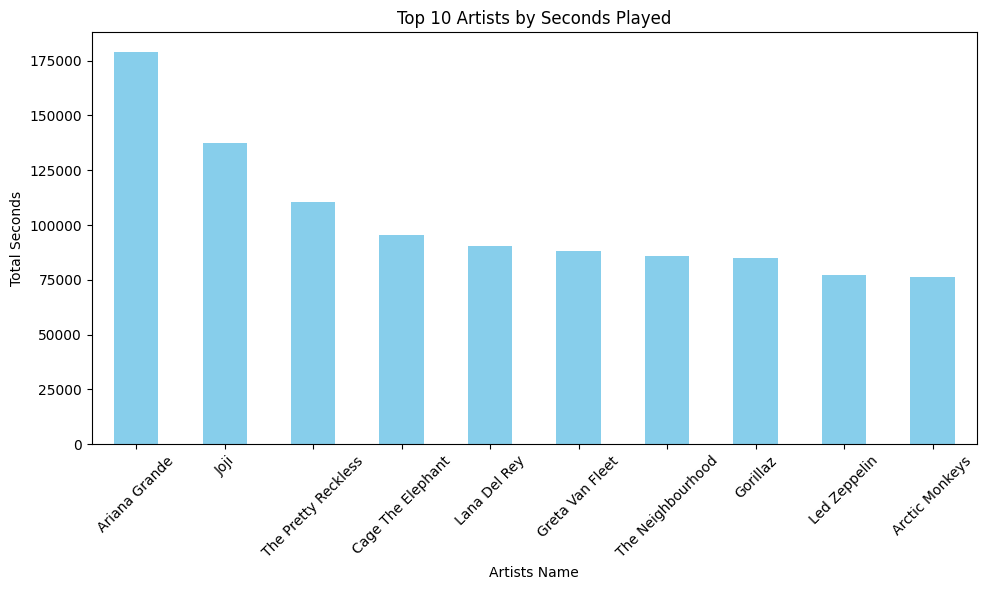

In [117]:
artists_df.head(10).plot(kind='bar', figsize=(10, 6), color='skyblue')

plt.title('Top 10 Artists by Seconds Played')
plt.xlabel('Artists Name')
plt.ylabel('Total Seconds')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### 2.6 Finding top 10 favorite songs
Find the top `ten` songs with the highest play time. Create a graph visualizing the results.

In [113]:
songs_df = df[["trackName", "secPlayed"]]
songs_df = songs_df.groupby("trackName")["secPlayed"].sum().sort_values(ascending=False)
songs_df.head(10)

trackName
Les                                 31403.364
O Children                          24558.414
When the Levee Breaks - Remaster    22631.721
Heartbeat                           22056.629
Afterthought                        21599.564
A Change Is Gonna Come              20414.317
Bones                               18860.916
FEEL.                               18696.637
Bad Ones (feat. Tegan and Sara)     18558.247
Love It If We Made It               17018.248
Name: secPlayed, dtype: float64

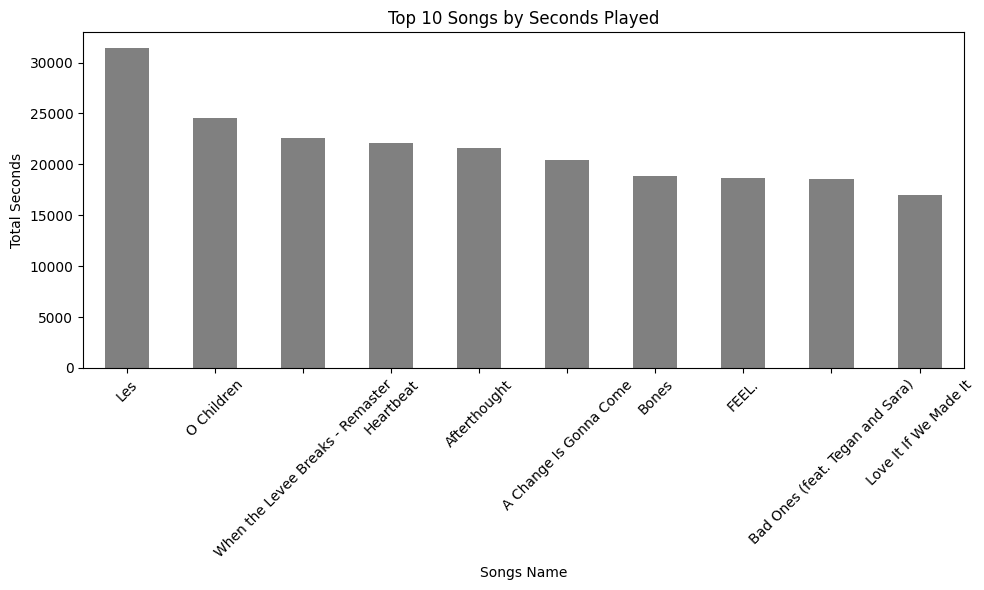

In [118]:
songs_df.head(10).plot(kind='bar', figsize=(10, 6), color='grey')

plt.title('Top 10 Songs by Seconds Played')
plt.xlabel('Songs Name')
plt.ylabel('Total Seconds')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Part 3: Further analysis

#### 3.0 Average listening time by hour
Generate a plot that displays the average amount of time that music is played for each hour of the day.

In [129]:
hour_df = df[["endTime", "secPlayed"]]
hour_df = hour_df.groupby(df["endTime"].dt.hour)["secPlayed"].sum()#.sort_values(ascending=False)
hour_df.head()

endTime
0    43644.743
1    11542.362
2     1911.741
3     2543.722
4     3726.363
Name: secPlayed, dtype: float64

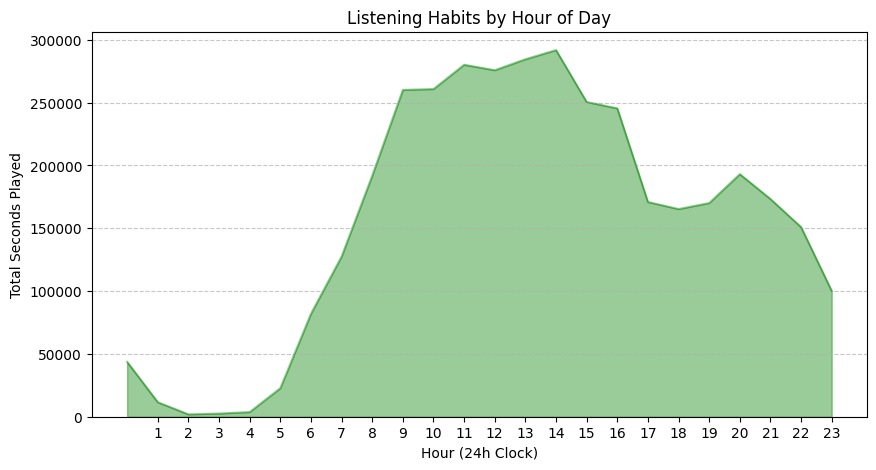

In [135]:
hour_df.plot(kind='area', figsize=(10, 5), color='green', alpha=0.4)

plt.title("Listening Habits by Hour of Day")
plt.xlabel("Hour (24h Clock)")
plt.ylabel("Total Seconds Played")
plt.xticks(range(1, 24)) # Show every hour on the X-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 3.1 Morning music and evening music
I think many people find that some types of music are more suitable for morning listening and some music is more suitable for evening listening. Create a plot that compares the play time of the artists *Leonard Cohen* and *Rage Against the Machine* on an hour-by-hour basis. See if there are any differences.

In [165]:
artists_to_compare = ["Leonard Cohen", "Rage Against The Machine"]
time_df = df[df["artistName"].isin(artists_to_compare)]
print(time_df["artistName"].unique())
time_df = time_df.groupby([df["endTime"].dt.hour, "artistName"])["secPlayed"].sum()
time_df.head()

['Leonard Cohen' 'Rage Against The Machine']


endTime  artistName              
0        Leonard Cohen               486.593
         Rage Against The Machine      2.024
1        Leonard Cohen                19.065
4        Leonard Cohen               271.905
         Rage Against The Machine     17.242
Name: secPlayed, dtype: float64

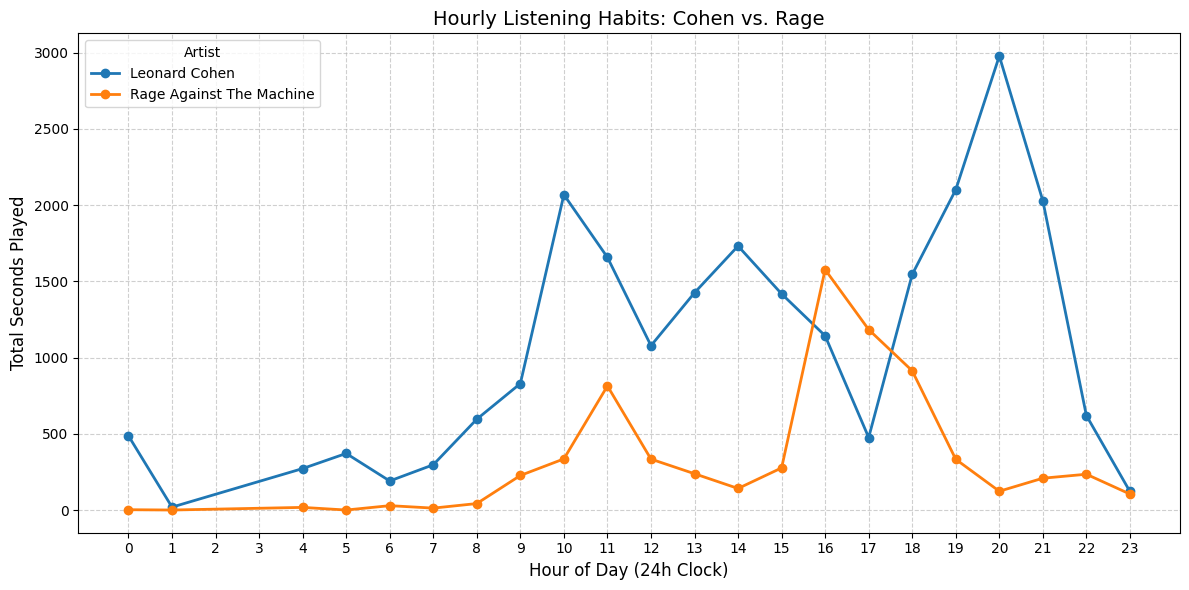

In [166]:
filtered_df = df[df["artistName"].isin(artists_to_compare)].copy()


comparison_df = filtered_df.groupby([filtered_df["endTime"].dt.hour, "artistName"])["secPlayed"].sum().unstack()

# Fill missing hours with 0 so the lines don't break
comparison_df = comparison_df.fillna(0)

# Plot with separate lines and colors
ax = comparison_df.plot(kind='line', marker='o', figsize=(12, 6), linewidth=2)

# Styling
plt.title("Hourly Listening Habits: Cohen vs. Rage", fontsize=14)
plt.xlabel("Hour of Day (24h Clock)", fontsize=12)
plt.ylabel("Total Seconds Played", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Artist", frameon=True)

plt.tight_layout()
plt.show()

#### 3.2 Analysing skipped songs
Determining whether a song was skipped or listened to can be challenging. For this analysis, we'll simplify by defining a skipped song as any track played for less than 30 seconds. Conversely, a song played for 30 seconds or more is considered listened to. \
 Add a column to your DataFrame to reflect this criteria: set the value to 1 if the song was played for less than 30 seconds (indicating a skipped song), and 0 if it was played for 30 seconds or longer.

In [170]:
df["isSkiped"] = np.where(df["secPlayed"] < 30, 1, 0)
df["isSkiped"].unique()

array([1, 0])

#### 3.3 Plotting skipped songs
Create a pie-chart that compares amount of skipped songs to amount of non-skipped songs.

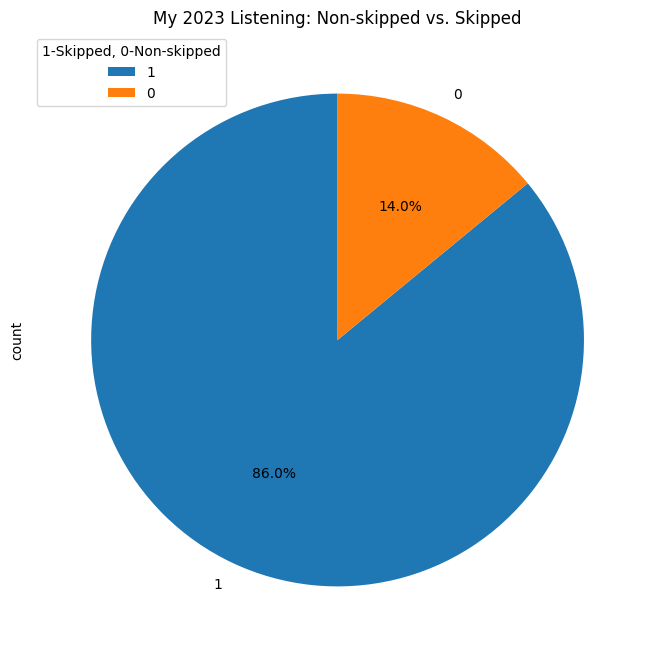

In [195]:
# Calculate totals
counts = df['isSkiped'].value_counts()
# Generate the Pie Chart
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8, 8))
plt.title('My 2023 Listening: Non-skipped vs. Skipped')
plt.legend(title = "1-Skipped, 0-Non-skipped", frameon=True)
plt.show()

#### 3.4 Artists by percentage of songs skipped
For each artist in the dataset, calculate which percentage of their songs was skipped. Store this information in a new DataFrame called `df_skipped`. Store the percentage of skipped songs in a new column named `SkipRate`\
\
**Example**: If an artist has **100** songs in your dataset and **25** of these were skipped, the percentage of skipped songs for this artist would be $\frac{25}{100}=25\%$

In [201]:
df_skipped = (df.groupby("artistName")["isSkiped"].mean() * 100).reset_index(name="SkipRate")
df_skipped.head()

,artistName,SkipRate
0,10cc,67.857143
1,2Pac,86.159844
2,3 Doors Down,50.000000
3,4 Non Blondes,72.131148
4,50 Cent,67.857143


#### 3.5 Comparing artists by skip-rate 
Find the `three` top artists with the lowest skip-rate and the `three` with the highest. Print their names, along with their skip-rate.

In [210]:
df_skipped.sort_values(by="SkipRate", inplace=True)
print(df_skipped.head(3))
df_skipped.tail(3)

        artistName   SkipRate
305  Gloria Gaynor   0.000000
645       Roc Boyz  11.111111
437          LACES  14.285714


,artistName,SkipRate
167,Cocteau Twins,100.0
187,D Smoke,100.0
417,Kelly Clarkson,100.0


## Part 4: God Is a Data Scientist - The Ariana Deep-Dive

#### 4.0 Ariana-DataFrame: 
Create a new DataFrame called *df_ariana*, containing only rows with music by Ariana Grande.

In [235]:
df_ariana = df[df["artistName"] == "Ariana Grande"]
#print(df_ariana["isSkiped"].unique())
print(df_ariana.shape)
df_ariana.head()

(19337, 5)


,endTime,artistName,trackName,secPlayed,isSkiped
10881,2023-01-01 01:17:00,Ariana Grande,7 rings,0.139,1
10882,2023-01-01 01:17:00,Ariana Grande,7 rings,0.487,1
10883,2023-01-01 01:17:00,Ariana Grande,positions,0.417,1
10887,2023-01-01 01:17:00,Ariana Grande,Santa Baby,12.293,1
10888,2023-01-01 01:17:00,Ariana Grande,Right There (feat. Big Sean),22.929,1


#### 4.1 Average skip rate
Create a histogram of the distribution of the skip-rate values of the different artists in your DataFrame  `df_skipped`, with skip rates on one axis and number of artists on the other. \
\
Then, retrieve the skip rate for Ariana Grande from your DataFrame `df_skipped`. Run the code in the cell below. Where on this distribution does Ariana Grande fall? Do I skip her songs more than average, or less?

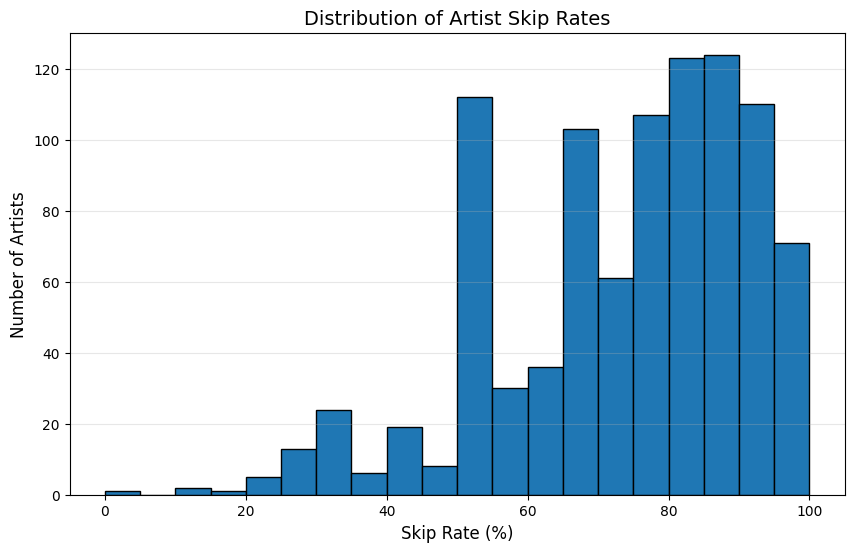

In [215]:
plt.figure(figsize=(10, 6))
plt.hist(df_skipped["SkipRate"], bins=20, edgecolor='black')

# Add labels and title
plt.title("Distribution of Artist Skip Rates", fontsize=14)
plt.xlabel("Skip Rate (%)", fontsize=12)
plt.ylabel("Number of Artists", fontsize=12)

# Optional: Add a grid for easier reading
plt.grid(axis='y', alpha=0.3)

plt.show()

In [234]:
Ariana_R = df_skipped.loc[df_skipped["artistName"] == "Ariana Grande", "SkipRate"].values[0]
Average_R = df_skipped["SkipRate"].mean()

print(f"Ariana Grande Skip Rate: {round(Ariana_R,2)}%")
print(f"Average Skip Rate (All Artists): {round(Average_R,2)}%")

Ariana Grande Skip Rate: 99.53%
Average Skip Rate (All Artists): 73.05%


### Part 4: Questions
Q1: Did I skip a lot of Ariana Grande's songs, or did I not, compared to the rest of the dataset? \
Ans: Yes, it seems you skiped a lot of Ariana songs than average artist. \
Q2: What might be some possible reasons for Ariana Grande to be my nr.1 artist? \
Ans:It could be the reason that- according to Total Time played by artist and Total Count of songs by a artist, Ariana is on the top. The following cells showing the result.


In [239]:
df.groupby("artistName")["secPlayed"].sum().sort_values(ascending=False).reset_index(name="Totaltime").head()

,artistName,Totaltime
0,Ariana Grande,178996.003
1,Joji,137229.562
2,The Pretty Reckless,110293.430
3,Cage The Elephant,95587.575
4,Lana Del Rey,90543.113


In [240]:
df.groupby("artistName")["secPlayed"].count().sort_values(ascending=False).reset_index(name="Totaltime").head()

,artistName,Totaltime
0,Ariana Grande,19337
1,Cage The Elephant,4627
2,Joji,3611
3,The Pretty Reckless,3278
4,Lana Del Rey,3028
